HW 2/1

In [43]:
import matplotlib.pyplot as plt
from matplotlib import rcParams # detailed parameter setting
""" more details on customization: https://matplotlib.org/stable/tutorials/introductory/customizing.html """
from typing import Dict, List, Union


# some type hints in the header of the function
def my_plotter(x: List[float], y: Union[List[float], List[List[float]]], layout: Dict = {}, names: List[str] = None) -> None:
    """ inline for loop is called 'list comprehension' """
    y = [y] if all(isinstance(item, float) for item in y) else y
    
    plt.figure(figsize=(8, 4))
    lines = []
    show_legend = True if names is not None else False
    # show_legend = True if names else False  -> here is fine, but be cautious bc 0, empty str and empty list will be evaulated to False

    """ setup some basic key-word arguments for plot line """
    plot_kwargs = {
        'linestyle': 'solid',
        'linewidth': 4
    }
    if names is not None:
        show_legend = True
        if len(names) != len(y):
            raise ValueError("Length of names is not matching with number of plotted y lists.")

    """ 'enumerate' add a counter to the loop """
    for i, y_item in enumerate(y):
        if show_legend:
            plot_kwargs['label'] = names[i]
        _line = plt.plot(x, y_item, **plot_kwargs)
        lines.append(_line)

    if show_legend:
        plt.legend(fontsize=16)
    if 'title' in layout:
        plt.title(layout['title'], fontsize=20)
        rcParams['axes.titlepad'] = 30 # moving the title a little further away from the plot
    if 'x_label' in layout:
        plt.xlabel(layout['x_label'], fontsize=16)
        rcParams['axes.labelpad'] = 20 # moving the ax label a little further away from the plot

    if 'y_label' in layout:
        plt.ylabel(layout['y_label'], fontsize=16)
        rcParams['axes.labelpad'] = 20 # moving the ax label a little further away from the plot

    if 'figsize' in layout:
        plt.figure(figsize=layout['figsize'])  

    if 'grid' in layout and layout['grid']:
        plt.grid()

    if 'x_lim' in layout:   
        plt.xlim(layout['x_lim'])
    
    if 'y_lim' in layout:
        plt.ylim(layout['y_lim'])  

    if 'legend_loc' in layout:
        plt.legend(loc=layout['legend_loc'], fontsize=16)
    

    """ enhance axes """
    ax = plt.gca() # gca: get current axes
    ax.axhline(linestyle='--', color='black', linewidth=1)
    plt.show()

In [44]:
import numpy as np

strike = 100
step_size = 0.001

x_stock_price = np.arange(0, 2 * strike, step_size)
y_forward_payoff = np.array([x - strike for x in x_stock_price])

y_forward_payoff__short = y_forward_payoff * (-1)
y_forward_payoff__short

array([100.   ,  99.999,  99.998, ..., -99.997, -99.998, -99.999],
      shape=(200000,))

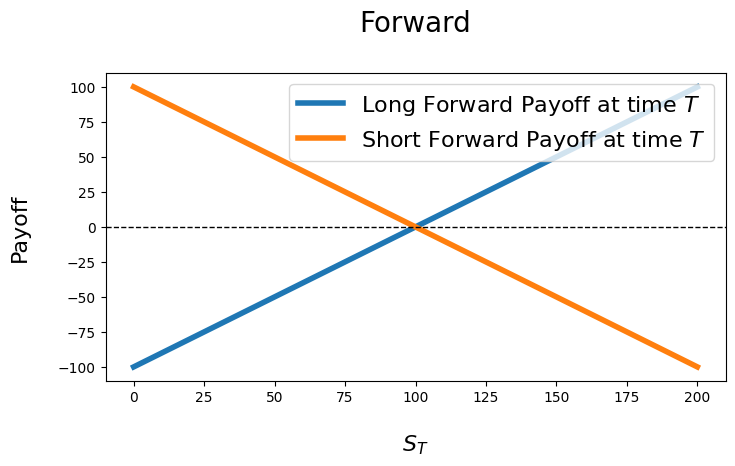

In [45]:
layout = {'title': 'Forward', 'x_label': '$S_{T}$', 'y_label': 'Payoff'}
my_plotter(x_stock_price, [y_forward_payoff, y_forward_payoff__short], layout=layout, names=['Long Forward Payoff at time $T$', 'Short Forward Payoff at time $T$'])


HW 2/2

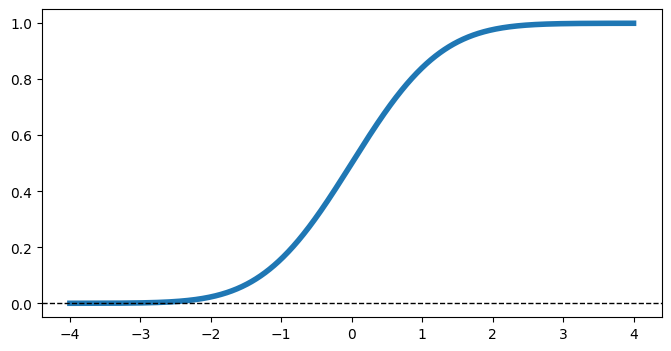

In [46]:
from scipy.stats import norm
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

x = np.linspace(-4, 4, 1000)
y = norm.cdf(x)

my_plotter(x, y)

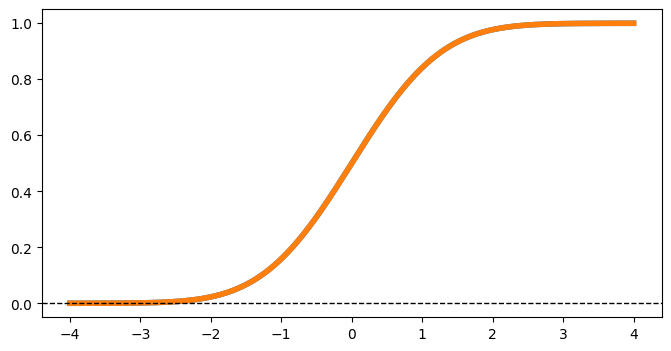

In [47]:
from scipy.special import erf
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.erf.html

x = np.linspace(-4, 4, 1000)
# numpy vectorizes the calculaction
y_erf = 0.5 * (1.0 + erf(x / np.sqrt(2)))

# plotting both results
my_plotter(x, [y, y_erf])

In [48]:
"""The pricing function of European call option"""
def black_scholes_eur_call(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> np.ndarray:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    price_call = N_d1_vec * S0 - K_vec * np.exp((-1.0)*r*T) * N_d2_vec

    # Calculate Greeks
    delta = N_d1_vec
    gamma = norm.pdf(d1_vec) / (S0 * sigma * T**0.5)
    vega = S0 * norm.pdf(d1_vec) * T**0.5
    theta = -(S0 * norm.pdf(d1_vec) * sigma) / (2 * T**0.5) - r * K_vec * np.exp((-1.0)*r*T) * N_d2_vec
    rho = K_vec * T * np.exp((-1.0)*r*T) * N_d2_vec

    
    return price_call, delta, gamma, vega, theta, rho

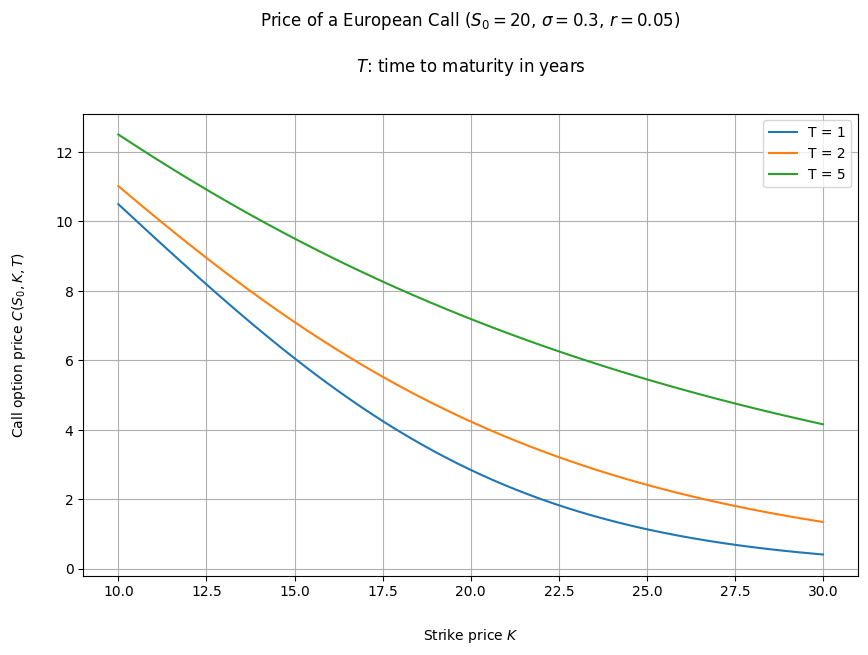

In [49]:
# Strike prices for which the option price is calculated
K_vec = np.arange(10, 30, 0.01)

# Time to maturities (in year fractions)
T_vec = [1.0, 2.0, 5.0]

prices_to_plot = []
for _T in T_vec:
    prices_to_plot.append(black_scholes_eur_call(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec)[0]) # [0] to get the price, the rest are Greeks

plt.figure(figsize=(10, 6))

for prices, T in zip(prices_to_plot, T_vec):
    plt.plot(K_vec, prices, label=f"T = {int(T)}")

plt.title(
    'Price of a European Call ($S_0 = 20$, $\\sigma = 0.3$, $r = 0.05$)\n\n'
    '$T$: time to maturity in years'
)

plt.xlabel('Strike price $K$')
plt.ylabel('Call option price $C(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()

HW 2/3

In [50]:
def black_scholes_eur_put(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> tuple:
    """
    Black-Scholes pricer of European put option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    # JAVÍTVA: put opció helyes képlete: K*e^(-rT)*N(-d2) - S0*N(-d1)
    price_put = K * np.exp(-r * T) * norm.cdf(-d2_vec) - S0 * norm.cdf(-d1_vec)

    # Calculate Greeks
    delta = norm.cdf(d1_vec) - 1  # put delta = N(d1) - 1
    gamma = norm.pdf(d1_vec) / (S0 * sigma * T**0.5)  # gamma ugyanaz, mint call-nál
    vega = S0 * norm.pdf(d1_vec) * T**0.5  # vega ugyanaz, mint call-nál
    
    # JAVÍTVA: put theta helyes képlete
    theta = -(S0 * norm.pdf(d1_vec) * sigma) / (2 * T**0.5) + r * K * np.exp(-r * T) * norm.cdf(-d2_vec)
    
    # JAVÍTVA: put rho helyes képlete
    rho = -K * T * np.exp(-r * T) * norm.cdf(-d2_vec)
    
    return price_put, delta, gamma, vega, theta, rho

HW 2/4

In [51]:
S0=100
K=100
T=1
r=0.05
sigma=0.2
K_vec = 100

C = black_scholes_eur_call(r=r, T=T, S0=S0, sigma=sigma, K=K_vec)[0]
P = black_scholes_eur_put(r=r, T=T, S0=S0, sigma=sigma, K=K_vec)[0]

print(f"Call price: {C:.4f}")
print(f"Put price: {P:.4f}")

if np.isclose(C - P, S0 - K * np.exp(-r * T)):
    print("Put-call parity holds.")
else:
    print("Put-call parity does not hold.")

Call price: 10.4506
Put price: 5.5735
Put-call parity holds.
